In [1]:
#Load Mosaics

from pathlib import Path
from preprocessing import load_data
import matplotlib.pyplot as plt
import numpy as np

data_dir = Path("../data")

img_mosaic, mask_mosaic, transform, crs = load_data(data_dir)

In [2]:
# Extract RGB (R, G, B order for plotting)
red = img_mosaic[2]
green = img_mosaic[1]
blue = img_mosaic[0]

In [3]:
#Stack rgb
rgb = np.stack([red, green, blue], axis=-1)

In [4]:
#Normalize to display

def normalize(img):
    img = img.astype(np.float32)
    img_min = np.percentile(img, 2)
    img_max = np.percentile(img, 98)
    img = (img - img_min) / (img_max - img_min)
    return np.clip(img, 0, 1)

rgb_norm = normalize(rgb)

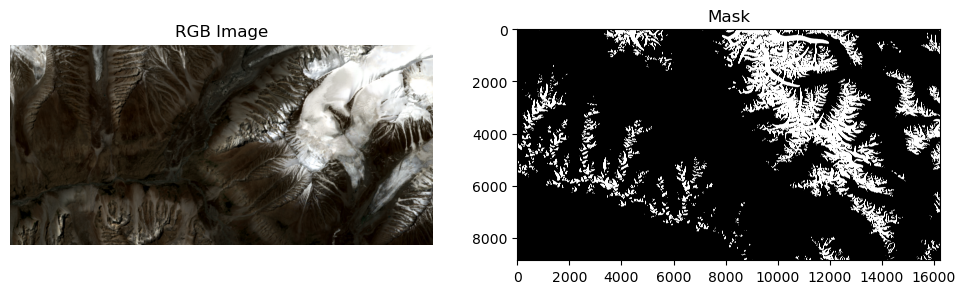

In [12]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_norm)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_mosaic[0], cmap="gray")
plt.title("Mask")

plt.show()

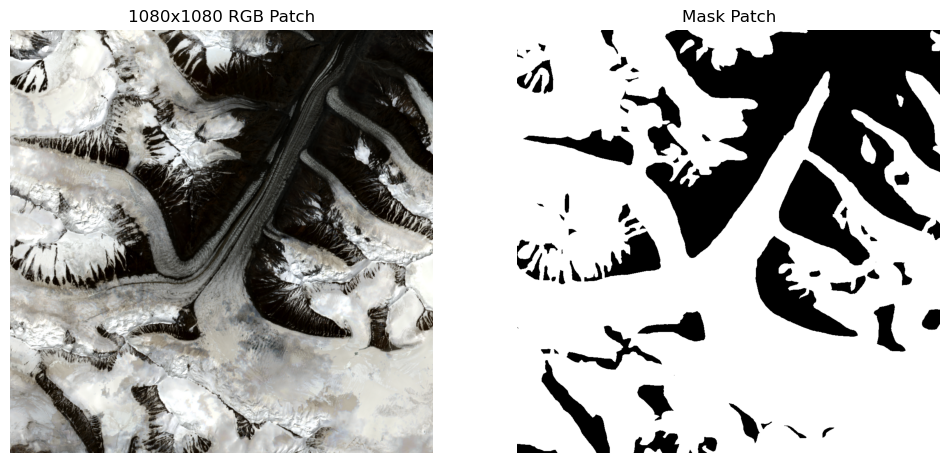

In [12]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from preprocessing import load_data

# Load full mosaic
data_dir = Path("../data")
img_mosaic, mask_mosaic, transform, _ = load_data(data_dir)

# ---- Choose the glacier patch ----
y, x = 3072, 11000   # change this to move around

PATCH_SIZE_y = 1080
PATCH_SIZE_x = 1080

# Extract patch
img_patch = img_mosaic[:, y:y+PATCH_SIZE_y, x:x+PATCH_SIZE_x]
mask_patch = mask_mosaic[:, y:y+PATCH_SIZE_y, x:x+PATCH_SIZE_x]

# ---- Extract RGB ----
red = img_patch[2]
green = img_patch[1]
blue = img_patch[0]

rgb = np.stack([red, green, blue], axis=-1)

# Normalize and show
def normalize(img):
    p2, p98 = np.percentile(img, (2, 98))
    img = (img - p2) / (p98 - p2)
    return np.clip(img, 0, 1)

rgb_norm = normalize(rgb)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_norm)
plt.title("1080x1080 RGB Patch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_patch[0], cmap="gray")
plt.title("Mask Patch")
plt.axis("off")

plt.savefig(
    "assets/1080x1080 RGB Patch_transparent.png",
    dpi=300,                # DPI doesn't matter much for SVG but safe to include
    transparent=True,
    bbox_inches="tight"     # removes extra whitespace
)
plt.savefig(
    "assets/1080x1080 RGB Patch_white_bg.png",
    dpi=300,
    transparent=False,
    facecolor="white",      # ensures proper background
    bbox_inches="tight"
)

plt.show()



In [3]:
# Get DEM
dem = img_mosaic[6]

In [4]:
# Compute Terrain Features:
from preprocessing import compute_terrain_features

terrain_features = compute_terrain_features(dem, transform, _)

In [13]:
img_patch = img_mosaic[:, y:y+PATCH_SIZE_y, x:x+PATCH_SIZE_x]

terrain_patch = np.stack([
    t[y:y+PATCH_SIZE_y, x:x+PATCH_SIZE_x] for t in terrain_features
])

In [14]:
# Combine:
full_patch = np.concatenate([img_patch, terrain_patch], axis=0)
print(full_patch.shape)

(18, 1080, 1080)


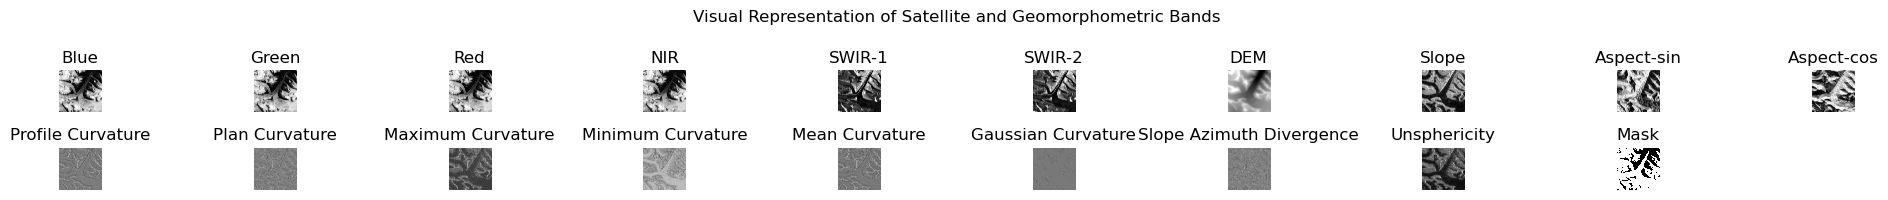

In [18]:
# Plot each band
import matplotlib.pyplot as plt

num_bands = full_patch.shape[0]

plt.figure(figsize=(20, 2))

band_names = [
    "Blue", "Green", "Red", "NIR", "SWIR-1", "SWIR-2", "DEM",
    "Slope", "Aspect-sin", "Aspect-cos",
    "Profile Curvature", "Plan Curvature",
    "Maximum Curvature", "Minimum Curvature", "Mean Curvature",
    "Gaussian Curvature", "Slope Azimuth Divergence", "Unsphericity"
]

# ---- Plot all bands ----
for i in range(num_bands):
    plt.subplot(2, 10, i + 1)

    band = full_patch[i]

    # Normalize each band individually for visibility
    p2, p98 = np.percentile(band, (2, 98))
    band_norm = (band - p2) / (p98 - p2)
    band_norm = np.clip(band_norm, 0, 1)

    plt.imshow(band_norm, cmap="gray")
    plt.title(band_names[i])
    plt.axis("off")

# ---- Plot mask ----
plt.subplot(2, 10, num_bands + 1)
plt.imshow(mask_patch[0], cmap="gray", interpolation='nearest', vmin=0, vmax=1)
plt.title("Mask")
plt.axis("off")

plt.suptitle("Visual Representation of Satellite and Geomorphometric Bands")
plt.subplots_adjust(wspace=0.02, hspace=0)
plt.tight_layout()

plt.savefig(
    "assets/Sat+Geo_transparent.png",
    dpi=300,                # DPI doesn't matter much for SVG but safe to include
    transparent=True,
    bbox_inches="tight"     # removes extra whitespace
)
plt.savefig(
    "assets/Sat+Geo_white_bg.png",
    dpi=300,
    transparent=False,
    facecolor="white",      # ensures proper background
    bbox_inches="tight"
)

plt.show()

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def normalize(band):
    p2, p98 = np.percentile(band, (2, 98))
    return np.clip((band - p2) / (p98 - p2 + 1e-6), 0, 1)

def save_image(img, title, path, cmap=None):
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close()   # IMPORTANT (prevents memory issues)


# ---------- 1. RGB ----------
rgb = np.stack([
    full_patch[2],  # Red
    full_patch[1],  # Green
    full_patch[0]   # Blue
], axis=-1)

rgb = normalize(rgb)
save_image(rgb, "RGB", "assets/rgb.png")


# ---------- 2. NDSI ----------
green = full_patch[1]
swir1 = full_patch[4]

ndsi = (green - swir1) / (green + swir1 + 1e-6)
ndsi = normalize(ndsi)

save_image(ndsi, "NDSI (Snow Index)", "assets/ndsi.png", cmap="coolwarm")


# ---------- 3. DEM ----------
dem = normalize(full_patch[6])
save_image(dem, "Elevation (DEM)", "assets/dem.png", cmap="terrain")


# ---------- 4. Mask ----------
mask = mask_patch[0]
save_image(mask, "Mask", "assets/mask.png", cmap="gray")

In [26]:
import os
os.chdir("..")
os.getcwd()

'E:\\Glacier_Image_Segmentation_Research\\Glacier-Analogy'

In [27]:
os.listdir()

['.git',
 '.gitignore',
 '.idea',
 '.ipynb_checkpoints',
 'config',
 'data',
 'dataset',
 'environment.yml',
 'inference',
 'main.py',
 'preprocessing',
 'README.md',
 'runs',
 'src',
 'tt.py',
 'utils']

In [28]:
from src.dataset.dataset import GlacierDataset

In [29]:
dataset = GlacierDataset(path=Path("./dataset/"),
                             patch_size=512,
                             overlap=1)

In [30]:
glaciers = 0
bgs = 0
temp = 512*512
for _, mask in dataset:
    glaciers += mask.sum()
    bgs += (temp-mask.sum())

glaciers = glaciers.item()
bgs = bgs.item()

aoi_glaciers = mask_mosaic.sum()
aoi_bgs = mask_mosaic.size - mask_mosaic.sum()
glaciers, bgs

(22341224.0, 79370592.0)

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid", context="talk")

labels = ["Glaciers", "Background"]


def annotate(ax, values):
    total = sum(values)
    for i, v in enumerate(values):
        pct = (v / total) * 100
        ax.text(
            i,
            v + max(values) * 0.01,
            f"{int(v)}\n({pct:.1f}%)",
            ha='center',
            va='bottom',
            fontsize=20
        )


def plot_and_save(values, title, filename):
    plt.figure(figsize=(10, 7))
    
    ax = sns.barplot(x=labels, y=values, color="#6CB48A")
    # plt.title(title)
    plt.ylabel("Frequency")
    plt.xlabel("Class")

    annotate(ax, values)

    plt.tight_layout()

    # Save PNG (Slides-friendly)
    plt.savefig(
        f"preprocessing/assets/{filename}.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    # Save SVG (optional, for papers)
    plt.savefig(
        f"preprocessing/assets/{filename}.svg",
        format="svg",
        bbox_inches="tight"
    )

    plt.close()   # IMPORTANT


# ----------- Dataset Distribution -----------
plot_and_save(
    [glaciers, bgs],
    "Dataset Pixel Distribution",
    "dataset_distribution"
)

# ----------- AOI Distribution -----------
plot_and_save(
    [aoi_glaciers, aoi_bgs],
    "AOI Pixel Distribution",
    "aoi_distribution"
)